In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# Settings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [6]:
# Load the dataset from Excel
df = pd.read_excel('Telco_Churn_Analysis.xlsx', sheet_name='RAW DATA')

print(f"✅ Dataset loaded successfully from Excel!")
print(f"Shape: {df.shape}")
print(f"Customers: {df.shape[0]:,}")
print(f"Features: {df.shape[1]}")

# Show column names
print(f"\nColumns in dataset:")
print(df.columns.tolist())

✅ Dataset loaded successfully from Excel!
Shape: (7043, 26)
Customers: 7,043
Features: 26

Columns in dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnNumeric', 'TenureGroup', 'ChargeGroup', 'SimpleCLV', 'ContractNumeric']


In [7]:
# First look at data
print("First 5 rows:")
print(df.head())

print("\n" + "="*60)
print("Dataset Info:")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("Basic Statistics:")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("Missing Values:")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("Churn Distribution:")
print("="*60)
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn']=='Yes').mean()*100:.2f}%")

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No      

In [8]:
# Clean TotalCharges column (has spaces instead of numbers for new customers)
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Verify cleaning
print(f"✅ TotalCharges converted to numeric")
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Check cleaned data
print("\nTotalCharges statistics:")
print(df['TotalCharges'].describe())

✅ TotalCharges converted to numeric
Missing values in TotalCharges: 0

TotalCharges statistics:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [9]:
# Create a copy for ML
df_ml = df.copy()

# Convert target variable to binary (0/1)
df_ml['Churn'] = (df_ml['Churn'] == 'Yes').astype(int)

print("Target variable distribution:")
print(df_ml['Churn'].value_counts())
print(f"\nChurn Rate: {df_ml['Churn'].mean()*100:.2f}%")

# Convert binary Yes/No columns to 1/0
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 
    'PaperlessBilling'
]

for col in binary_cols:
    df_ml[col] = (df_ml[col] == 'Yes').astype(int)

print(f"\n✅ Converted {len(binary_cols)} binary columns to numeric")

# Convert SeniorCitizen to consistent format (already 0/1)
print(f"\nSeniorCitizen unique values: {df_ml['SeniorCitizen'].unique()}")

Target variable distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%

✅ Converted 4 binary columns to numeric

SeniorCitizen unique values: [0 1]


In [10]:
# Define features we'll use for prediction
features_to_use = [
    # Demographics
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    
    # Services
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    
    # Account info
    'tenure', 'Contract', 'PaperlessBilling', 
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]

# Select feature columns
X = df_ml[features_to_use].copy()
y = df_ml['Churn']

print(f"Features selected: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nFeatures:")
for i, col in enumerate(X.columns, 1):
    print(f"{i:2d}. {col}")

Features selected: 19
Samples: 7043

Features:
 1. gender
 2. SeniorCitizen
 3. Partner
 4. Dependents
 5. PhoneService
 6. MultipleLines
 7. InternetService
 8. OnlineSecurity
 9. OnlineBackup
10. DeviceProtection
11. TechSupport
12. StreamingTV
13. StreamingMovies
14. tenure
15. Contract
16. PaperlessBilling
17. PaymentMethod
18. MonthlyCharges
19. TotalCharges


In [11]:
# Get categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns: {len(categorical_cols)}")
print(categorical_cols.tolist())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\n✅ One-hot encoding complete")
print(f"Original features: {X.shape[1]}")
print(f"After encoding: {X_encoded.shape[1]}")

# Display new feature names
print("\nFinal features for model:")
for i, col in enumerate(X_encoded.columns, 1):
    print(f"{i:2d}. {col}")

Categorical columns: 11
['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

✅ One-hot encoding complete
Original features: 19
After encoding: 30

Final features for model:
 1. SeniorCitizen
 2. Partner
 3. Dependents
 4. PhoneService
 5. tenure
 6. PaperlessBilling
 7. MonthlyCharges
 8. TotalCharges
 9. gender_Male
10. MultipleLines_No phone service
11. MultipleLines_Yes
12. InternetService_Fiber optic
13. InternetService_No
14. OnlineSecurity_No internet service
15. OnlineSecurity_Yes
16. OnlineBackup_No internet service
17. OnlineBackup_Yes
18. DeviceProtection_No internet service
19. DeviceProtection_Yes
20. TechSupport_No internet service
21. TechSupport_Yes
22. StreamingTV_No internet service
23. StreamingTV_Yes
24. StreamingMovies_No internet service
25. StreamingMovies_Yes
26. Contract_One year
27. Contract_Two year
28. PaymentMethod_Credit card (autom

In [12]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same churn ratio in both sets
)

print("Data Split Complete:")
print("="*50)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nTraining set churn rate: {y_train.mean()*100:.2f}%")
print(f"Testing set churn rate:  {y_test.mean()*100:.2f}%")
print(f"\n✅ Stratification successful - both sets have similar churn rates")

Data Split Complete:
Training set: 5,634 samples (80.0%)
Testing set:  1,409 samples (20.0%)

Training set churn rate: 26.54%
Testing set churn rate:  26.54%

✅ Stratification successful - both sets have similar churn rates


In [13]:
print("Training Random Forest Model...")
print("="*50)

# Create model
model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth of trees
    min_samples_split=20,  # Minimum samples to split
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all CPU cores
)

# Train model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\nModel: Random Forest")
print(f"Number of trees: {model.n_estimators}")
print(f"Features used: {len(X_train.columns)}")

Training Random Forest Model...
✅ Model trained successfully!

Model: Random Forest
Number of trees: 100
Features used: 30


In [14]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of churn

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\n" + "="*60)
print("Detailed Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, 
                          target_names=['Retained', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n" + "="*60)
print("Confusion Matrix:")
print("="*60)
print(f"True Negatives (Correctly predicted Retained):  {cm[0,0]}")
print(f"False Positives (Predicted Churn, Actually Retained): {cm[0,1]}")
print(f"False Negatives (Predicted Retained, Actually Churned): {cm[1,0]}")
print(f"True Positives (Correctly predicted Churned):   {cm[1,1]}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print(f"• Model correctly identifies {accuracy*100:.1f}% of customers")
print(f"• Can catch {cm[1,1]/(cm[1,1]+cm[1,0])*100:.1f}% of churners before they leave")
print(f"• {cm[0,1]} false alarms (predicted churn but didn't)")

MODEL PERFORMANCE
Accuracy:  79.84%
ROC-AUC:   0.843

Detailed Classification Report:
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.87      1035
     Churned       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
True Negatives (Correctly predicted Retained):  936
False Positives (Predicted Churn, Actually Retained): 99
False Negatives (Predicted Retained, Actually Churned): 185
True Positives (Correctly predicted Churned):   189

INTERPRETATION:
• Model correctly identifies 79.8% of customers
• Can catch 50.5% of churners before they leave
• 99 false alarms (predicted churn but didn't)


In [15]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING CHURN")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# Save for later use
feature_importance.to_csv('feature_importance.csv', index=False)
print("\n✅ Feature importance saved to 'feature_importance.csv'")

TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING CHURN
                            Feature  Importance
                             tenure    0.187524
                       TotalCharges    0.158068
                     MonthlyCharges    0.108469
     PaymentMethod_Electronic check    0.075190
        InternetService_Fiber optic    0.071290
                  Contract_Two year    0.069089
                  Contract_One year    0.040621
                 OnlineSecurity_Yes    0.034386
                    TechSupport_Yes    0.030788
                   PaperlessBilling    0.020232
   OnlineBackup_No internet service    0.016949
 OnlineSecurity_No internet service    0.014088
                   OnlineBackup_Yes    0.013053
StreamingMovies_No internet service    0.012986
                  MultipleLines_Yes    0.012859

✅ Feature importance saved to 'feature_importance.csv'


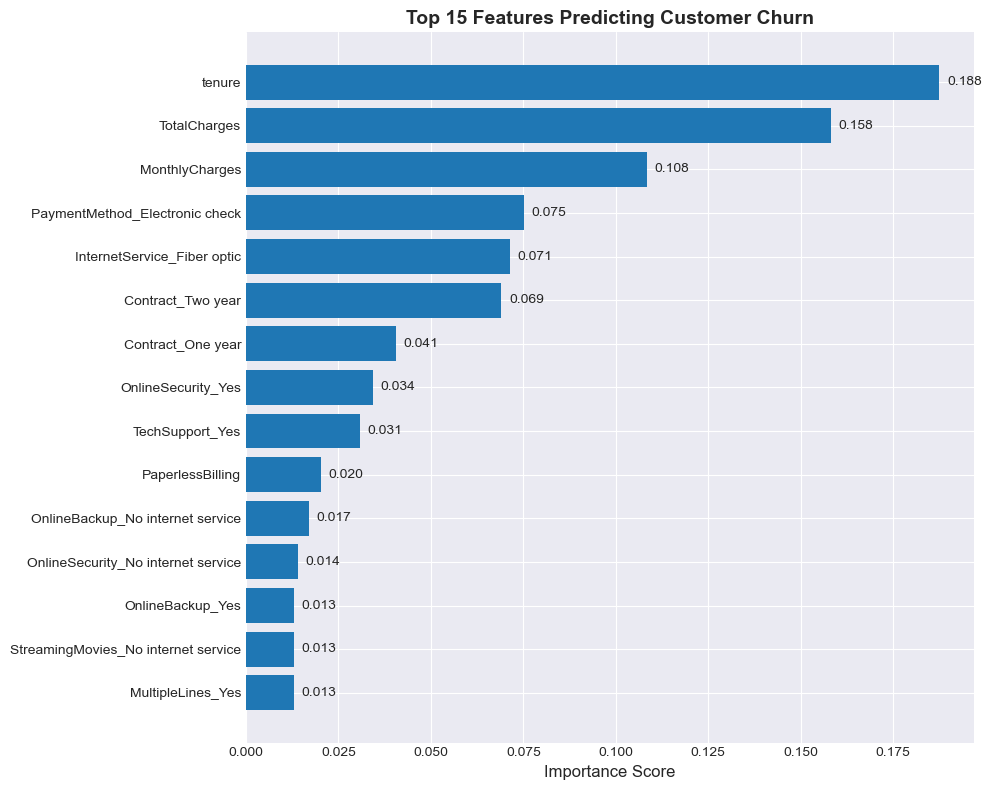

✅ Chart saved as 'feature_importance.png'


In [16]:
# Create feature importance chart
plt.figure(figsize=(10, 8))

# Top 15 features
top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Features Predicting Customer Churn', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top

# Add value labels
for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'feature_importance.png'")

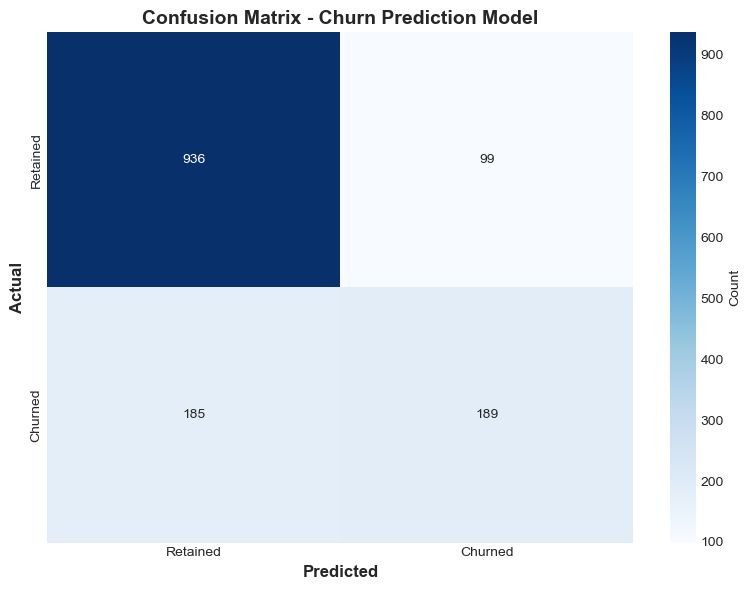

✅ Chart saved as 'confusion_matrix.png'


In [17]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Churn Prediction Model', 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'confusion_matrix.png'")

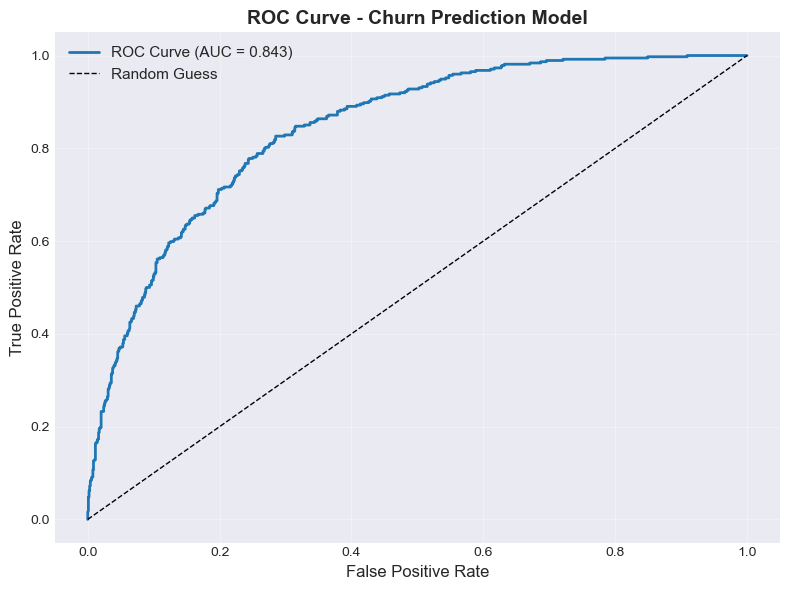

✅ Chart saved as 'roc_curve.png'


In [18]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Churn Prediction Model', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'roc_curve.png'")

In [19]:
# Predict churn probability for ALL customers
all_predictions = model.predict_proba(X_encoded)[:, 1]

# Add predictions to original dataframe
df_with_predictions = df.copy()
df_with_predictions['Churn_Probability'] = all_predictions
df_with_predictions['Predicted_Churn'] = (all_predictions > 0.5).astype(int)
df_with_predictions['Risk_Level'] = pd.cut(
    all_predictions,
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("CHURN RISK DISTRIBUTION")
print("="*60)
print(df_with_predictions['Risk_Level'].value_counts().sort_index())

print("\n" + "="*60)
print("PROBABILITY DISTRIBUTION:")
print("="*60)
print(df_with_predictions['Churn_Probability'].describe())

CHURN RISK DISTRIBUTION
Risk_Level
Low Risk       4392
Medium Risk    2160
High Risk       491
Name: count, dtype: int64

PROBABILITY DISTRIBUTION:
count    7043.000000
mean        0.266744
std         0.240612
min         0.000106
25%         0.056915
50%         0.193033
75%         0.442206
max         0.893719
Name: Churn_Probability, dtype: float64


In [20]:
# Filter high-risk customers (>70% churn probability)
high_risk = df_with_predictions[
    df_with_predictions['Churn_Probability'] > 0.7
].sort_values('Churn_Probability', ascending=False)

print(f"HIGH-RISK CUSTOMERS IDENTIFIED")
print("="*60)
print(f"Total high-risk customers: {len(high_risk)}")
print(f"Percentage of customer base: {len(high_risk)/len(df)*100:.1f}%")

print("\n" + "="*60)
print("HIGH-RISK CUSTOMER PROFILE:")
print("="*60)

print(f"\nAverage tenure: {high_risk['tenure'].mean():.1f} months")
print(f"Average monthly charges: ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"Average total charges: ${high_risk['TotalCharges'].mean():.2f}")

print("\nContract distribution:")
print(high_risk['Contract'].value_counts())

print("\nInternet service:")
print(high_risk['InternetService'].value_counts())

print("\nTech support:")
print(high_risk['TechSupport'].value_counts())

# Calculate potential revenue at risk
potential_revenue_loss = high_risk['MonthlyCharges'].sum() * 12
print(f"\n💰 ANNUAL REVENUE AT RISK: ${potential_revenue_loss:,.2f}")

HIGH-RISK CUSTOMERS IDENTIFIED
Total high-risk customers: 491
Percentage of customer base: 7.0%

HIGH-RISK CUSTOMER PROFILE:

Average tenure: 3.5 months
Average monthly charges: $82.11
Average total charges: $310.87

Contract distribution:
Contract
Month-to-month    491
Name: count, dtype: int64

Internet service:
InternetService
Fiber optic    471
DSL             20
Name: count, dtype: int64

Tech support:
TechSupport
No     471
Yes     20
Name: count, dtype: int64

💰 ANNUAL REVENUE AT RISK: $483,781.20


In [21]:
# Select relevant columns for export
export_columns = [
    'customerID', 'tenure', 'Contract', 'MonthlyCharges',
    'InternetService', 'TechSupport', 'Churn_Probability'
]

high_risk_export = high_risk[export_columns].copy()

# Add recommendation column
def get_recommendation(row):
    recommendations = []
    
    if row['Contract'] == 'Month-to-month':
        recommendations.append('Convert to annual contract')
    
    if row['TechSupport'] == 'No':
        recommendations.append('Offer TechSupport trial')
    
    if row['MonthlyCharges'] > 70:
        recommendations.append('Review pricing/offer discount')
    
    if row['tenure'] < 12:
        recommendations.append('Assign customer success manager')
    
    return ' | '.join(recommendations) if recommendations else 'Monitor closely'

high_risk_export['Recommended_Action'] = high_risk_export.apply(
    get_recommendation, axis=1
)

# Save to Excel
high_risk_export.to_excel('high_risk_customers.xlsx', index=False)

print(f"✅ Exported {len(high_risk_export)} high-risk customers to 'high_risk_customers.xlsx'")
print("\nTop 10 customers at highest risk:")
print(high_risk_export.head(10).to_string(index=False))

✅ Exported 491 high-risk customers to 'high_risk_customers.xlsx'

Top 10 customers at highest risk:
customerID  tenure       Contract  MonthlyCharges InternetService TechSupport  Churn_Probability                                                                                                     Recommended_Action
1069-XAIEM       1 Month-to-month           85.05     Fiber optic          No           0.893719 Convert to annual contract | Offer TechSupport trial | Review pricing/offer discount | Assign customer success manager
9300-AGZNL       1 Month-to-month           94.00     Fiber optic          No           0.891181 Convert to annual contract | Offer TechSupport trial | Review pricing/offer discount | Assign customer success manager
9497-QCMMS       1 Month-to-month           93.55     Fiber optic          No           0.888551 Convert to annual contract | Offer TechSupport trial | Review pricing/offer discount | Assign customer success manager
4910-GMJOT       1 Month-to-month   

<Figure size 1600x1400 with 0 Axes>

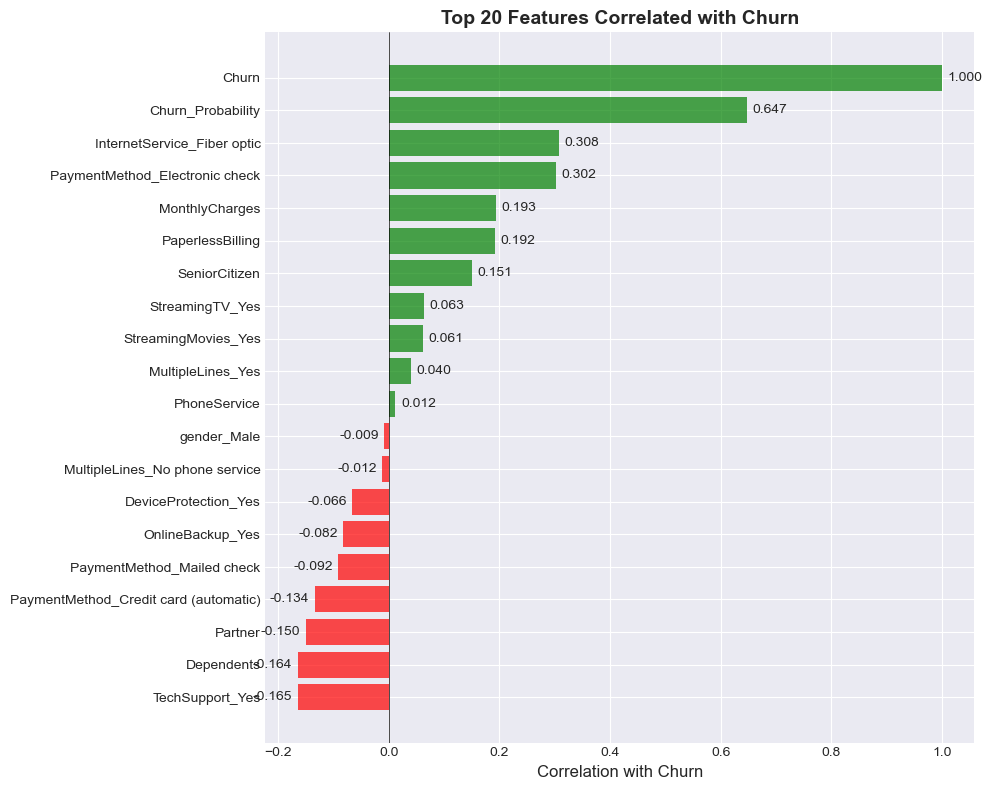

✅ Chart saved as 'correlation_analysis.png'


In [22]:
# Select numeric columns for correlation
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'SeniorCitizen', 'Churn_Probability']

# Add encoded categorical as binary
correlation_data = X_encoded.copy()
correlation_data['Churn'] = y
correlation_data['Churn_Probability'] = all_predictions

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(16, 14))

# Focus on correlations with Churn
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

# Plot top 20 correlations
top_corr = churn_correlations.head(20)

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Correlation with Churn', fontsize=12)
plt.title('Top 20 Features Correlated with Churn', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(top_corr.values):
    plt.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
             va='center', ha='left' if v > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'correlation_analysis.png'")

In [23]:
print("="*70)
print("MACHINE LEARNING MODEL - EXECUTIVE SUMMARY")
print("="*70)

print("\n📊 MODEL PERFORMANCE:")
print(f"   • Accuracy: {accuracy*100:.1f}%")
print(f"   • Can identify {cm[1,1]/(cm[1,1]+cm[1,0])*100:.1f}% of churners before they leave")
print(f"   • ROC-AUC Score: {roc_auc:.3f} (0.5=random, 1.0=perfect)")

print("\n🎯 TOP CHURN PREDICTORS:")
top_5_features = feature_importance.head(5)
for i, row in top_5_features.iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.1%} importance")

print(f"\n⚠️  HIGH-RISK CUSTOMERS:")
print(f"   • Total identified: {len(high_risk)} customers")
print(f"   • {len(high_risk)/len(df)*100:.1f}% of customer base")
print(f"   • Average churn probability: {high_risk['Churn_Probability'].mean()*100:.1f}%")
print(f"   • Annual revenue at risk: ${potential_revenue_loss:,.2f}")

print(f"\n💡 KEY INSIGHTS:")
print(f"   • {(high_risk['Contract']=='Month-to-month').sum()} high-risk customers on month-to-month contracts")
print(f"   • {(high_risk['TechSupport']=='No').sum()} high-risk customers lack TechSupport")
print(f"   • {len(high_risk[high_risk['tenure']<12])} high-risk customers are in first year")
print(f"   • Average monthly charge for high-risk: ${high_risk['MonthlyCharges'].mean():.2f}")

print("\n✅ ACTIONABLE RECOMMENDATIONS:")
print(f"   1. Proactively contact {len(high_risk)} high-risk customers")
print(f"   2. Offer contract conversion incentives (predicted to save {len(high_risk)*0.4:.0f} customers)")
print(f"   3. Bundle TechSupport with all plans")
print(f"   4. Implement early-tenure customer success program")

print("\n" + "="*70)
print("Analysis complete! Files saved:")
print("   • feature_importance.png")
print("   • confusion_matrix.png")
print("   • roc_curve.png")
print("   • correlation_analysis.png")
print("   • high_risk_customers.xlsx")
print("="*70)

MACHINE LEARNING MODEL - EXECUTIVE SUMMARY

📊 MODEL PERFORMANCE:
   • Accuracy: 79.8%
   • Can identify 50.5% of churners before they leave
   • ROC-AUC Score: 0.843 (0.5=random, 1.0=perfect)

🎯 TOP CHURN PREDICTORS:
   5. tenure: 18.8% importance
   8. TotalCharges: 15.8% importance
   7. MonthlyCharges: 10.8% importance
   29. PaymentMethod_Electronic check: 7.5% importance
   12. InternetService_Fiber optic: 7.1% importance

⚠️  HIGH-RISK CUSTOMERS:
   • Total identified: 491 customers
   • 7.0% of customer base
   • Average churn probability: 78.3%
   • Annual revenue at risk: $483,781.20

💡 KEY INSIGHTS:
   • 491 high-risk customers on month-to-month contracts
   • 471 high-risk customers lack TechSupport
   • 473 high-risk customers are in first year
   • Average monthly charge for high-risk: $82.11

✅ ACTIONABLE RECOMMENDATIONS:
   1. Proactively contact 491 high-risk customers
   2. Offer contract conversion incentives (predicted to save 196 customers)
   3. Bundle TechSupport 